In [1]:
import os, sys, glob


root = os.getcwd()
while root != "/" and not os.path.isdir(os.path.join(root, "modules")):
   root = os.path.dirname(root)


if root not in sys.path:
   sys.path.insert(0, root)


DATA_DIR = os.path.join(root, "output", "data")


if not os.path.exists(os.path.join(DATA_DIR, "df_raw.pkl")):
   hits = glob.glob(os.path.join(root, "**", "output", "data", "df_raw.pkl"), recursive=True)
   if hits:
       DATA_DIR = os.path.dirname(hits[0])


In [2]:
import os, sys
os.chdir("/Users/bachn/Documents/rat-model")  
import pickle
with open("output/data/df_ML_train.pkl", "rb") as f:
    df_ML_train = pickle.load(f)
with open("output/data/feature_names.pkl", "rb") as f:          
    feature_names = pickle.load(f)
with open("output/data/df_ML_test.pkl", "rb") as f:
    df_ML_test = pickle.load(f)

In [5]:
excluded_column = ['force_variation_rate', 'peak_sharp_max', 'peak_num']
duration_features = ["max_force", "avg_first_5", "avg_last_5", "pk_sharp_mean", "pk_sharp_min", "skewness"]
force_features = ["kurtosis", "total_press_duration", "pk_widths_max", "pk_widths_mean", "pk_widths_min"]

In [3]:
import numpy as np
from modules.Data import data_from_pickle
from modules.nn_models import GRUModel

df_raw, df_ML, row_train, row_valid, row_test, feature_names = data_from_pickle(base=DATA_DIR)

In [6]:
feature_names = [i for i in feature_names if i not in excluded_column]

In [7]:
x_train = df_ML_train[feature_names]
y_train = (df_ML_train["category"].astype(str) == "EXT").to_numpy(dtype=int)
x_test  = df_ML_test[feature_names]
y_test  = (df_ML_test["category"].astype(str) == "EXT").to_numpy(dtype=int)

print(x_test.shape, y_train.shape, x_test.shape, y_test.shape)
x_train.iloc[y_train == 0].max_force.mean() 

(2798, 14) (20355,) (2798, 14) (2798,)


np.float64(45.248568413619964)

/Users/bachn/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/bachn/miniconda3/lib/python3.12/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


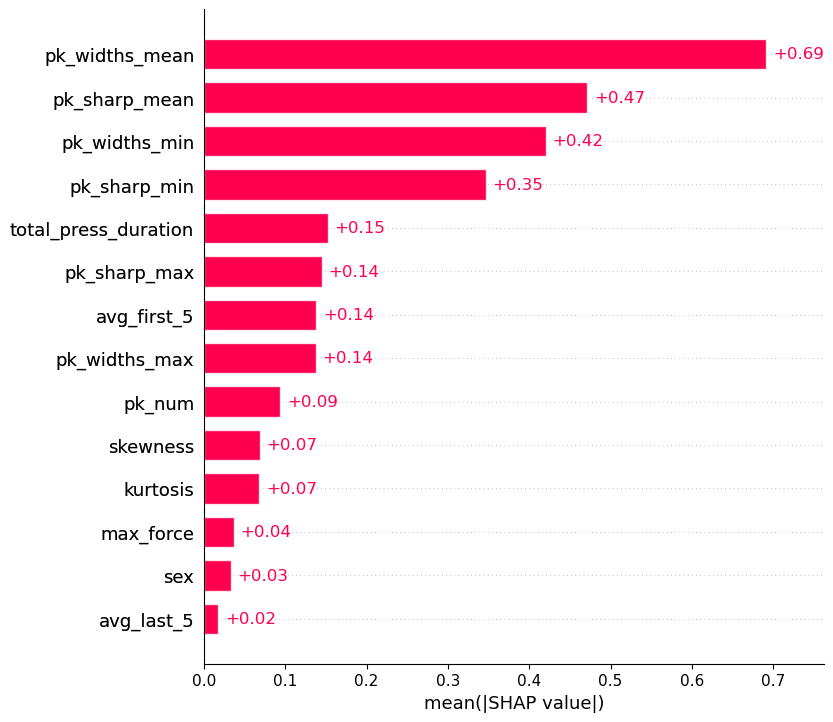

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import shap, matplotlib.pyplot as plt 

lr = LogisticRegression(C = 1.0, max_iter = 1000, solver = "liblinear", penalty = "l1")
lr.fit(x_train, y_train) 

expl_lr = shap.LinearExplainer(lr, x_train, feature_perturbation="interventional")
shap.plots.bar(expl_lr(x_test), max_display=30)
plt.show() 

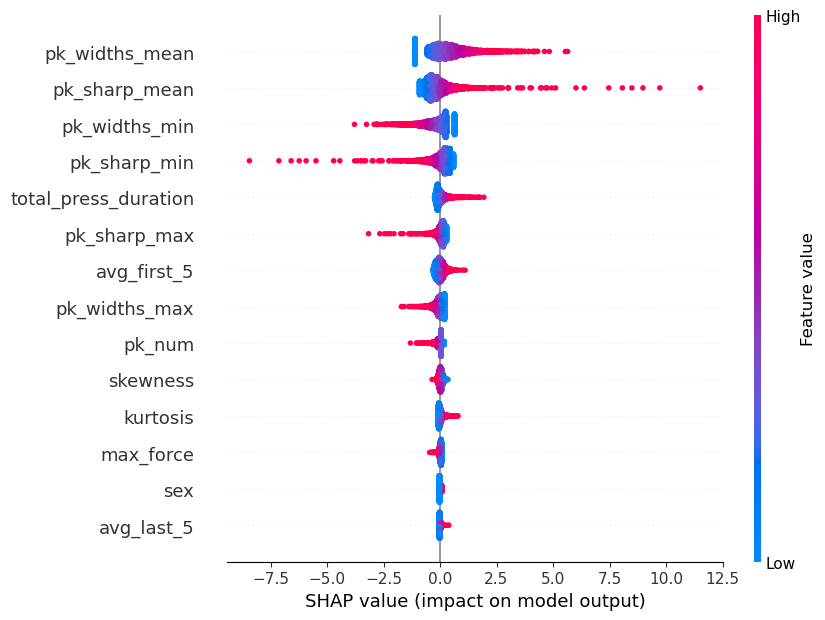

In [9]:
shap.plots.beeswarm(expl_lr(x_test), max_display=30) 
plt.show() 

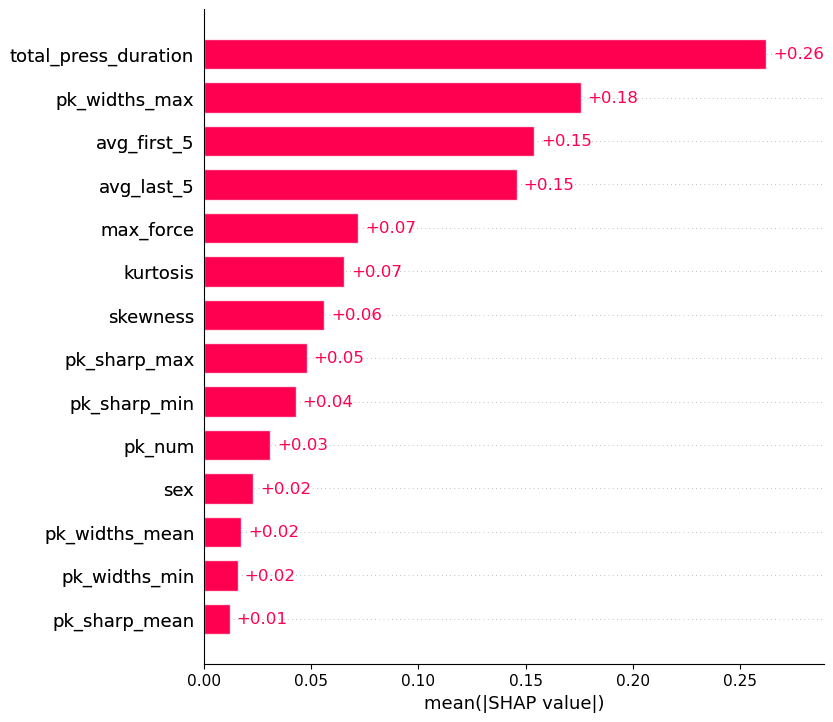

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    max_depth=3,
    min_samples_leaf=4,
    min_samples_split=6,
    n_estimators=60,
    subsample=0.8,
    random_state=42,
)
gb.fit(x_train, y_train) 
expl_gb = shap.Explainer(gb, x_train) 
shap.plots.bar(expl_gb(x_test), max_display=20)
plt.show()

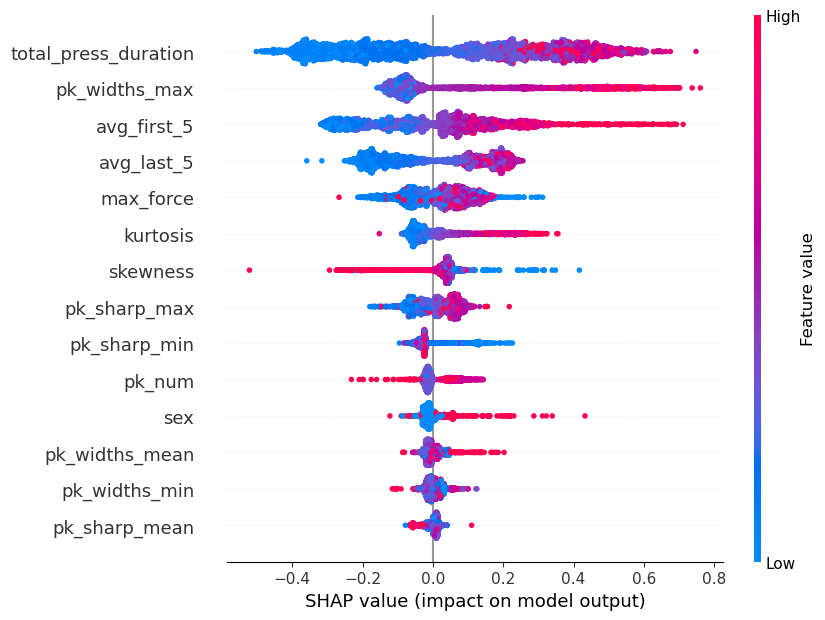

In [11]:
shap.plots.beeswarm(expl_gb(x_test), max_display=30) 
plt.show()

In [12]:
X_train_force = df_ML_train[force_features]
X_train_dur = df_ML_train[duration_features]
X_test_force = df_ML_test[force_features]
X_test_dur = df_ML_test[duration_features]

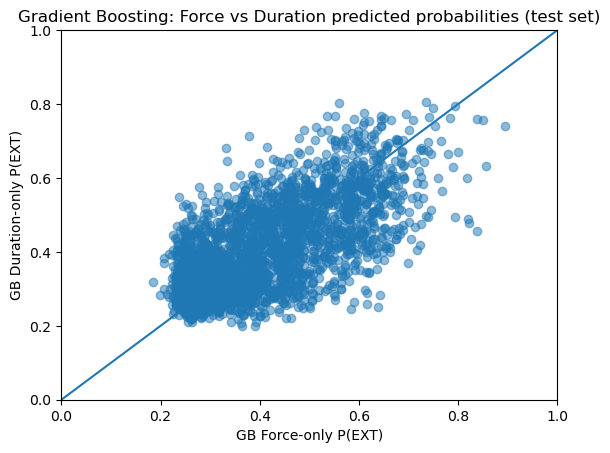

In [13]:
import matplotlib.pyplot as plt 
from sklearn.ensemble import GradientBoostingClassifier

gb_force = GradientBoostingClassifier(
    max_depth=4, 
    min_samples_leaf=4, 
    min_samples_split=8, 
    n_estimators=80, 
    subsample=0.8, 
    random_state=42
)

gb_dur = GradientBoostingClassifier(
    max_depth=3,
    min_samples_leaf=2,
    min_samples_split=8,
    n_estimators=60,
    subsample=0.6,
    random_state=42
)

gb_force.fit(X_train_force, y_train) 
gb_dur.fit(X_train_dur, y_train) 

p_force = gb_force.predict_proba(X_test_force)[:, 1]
p_dur = gb_dur.predict_proba(X_test_dur)[:, 1]

plt.figure()
plt.scatter(p_force, p_dur, alpha=0.5)
plt.plot([0, 1], [0, 1])  # y=x reference line
plt.xlim(0, 1); plt.ylim(0, 1)
plt.xlabel("GB Force-only P(EXT)")
plt.ylabel("GB Duration-only P(EXT)")
plt.title("Gradient Boosting: Force vs Duration predicted probabilities (test set)")
plt.show()

In [15]:
from sklearn.metrics import roc_auc_score
gb_full_model = GradientBoostingClassifier(
    max_depth=3,
    min_samples_leaf=3,
    min_samples_split=2,
    n_estimators=100,
    subsample=0.8,
    random_state=42
)

gb_full_model.fit(x_train, y_train)

p_full_model = gb_full_model.predict_proba(x_test)[:, 1]
auc_gb_full = roc_auc_score(y_test, p_full_model)
auc_gb_full

0.644478430567846

In [16]:
from sklearn.metrics import roc_auc_score

auc_gb_force = roc_auc_score(y_test, p_force)
auc_gb_dur = roc_auc_score(y_test, p_dur)
auc_gb_force, auc_gb_dur


(0.6008500805834498, 0.6226292541435283)

In [16]:
import numpy as np 
from rocauc_comparison import delong_roc_test 
p_full_vs_force = delong_roc_test(
    np.array(y_test), 
    np.array(p_full_model), 
    np.array(p_force)
)

p_full_vs_dur = delong_roc_test(
    np.array(y_test), 
    np.array(p_full_model), 
    np.array(p_dur)
)

p_full_vs_force, p_full_vs_dur

(array([[-8.81231597]]), array([[-3.01257755]]))

In [21]:
from scipy.stats import pearsonr

r, pval = pearsonr(p_force, p_dur)

print("Pearson r:", r)
print("p-value:", pval)


Pearson r: 0.661265256946457
p-value: 0.0


In [18]:
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression 
lr_force = LogisticRegression(C=0.06, max_iter=1000) 
lr_dur = LogisticRegression(C=0.79, max_iter=1000) 
lr_force.fit(X_train_force, y_train) 
lr_dur.fit(X_train_dur, y_train) 
p_force_lr = lr_force.predict_proba(X_test_force)[:, 1]
p_dur_lr = lr_dur.predict_proba(X_test_dur)[:, 1]
r_lr = np.corrcoef(p_force_lr, p_dur_lr)[0,1] 
r_squared_lr = r_lr**2 
print(r_lr) 
print(r_squared_lr) 
auc_lr_dur = roc_auc_score(y_test, p_dur_lr) 
auc_lr_force = roc_auc_score(y_test, p_force_lr)
print(auc_lr_dur)
print(auc_lr_force)

0.4925430517644885
0.24259865784147558
0.5426878534877457
0.5752680415015453


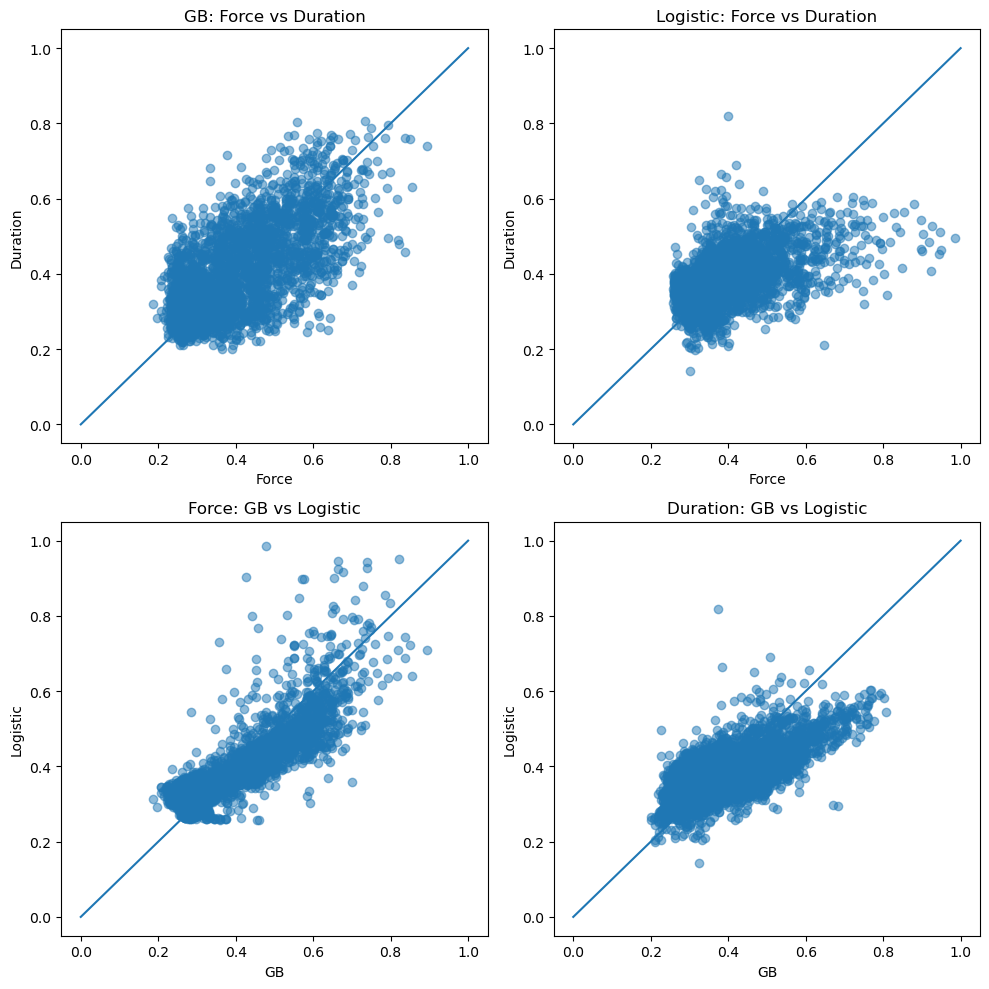

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(10,10))

# 1 — GB Force vs Duration
ax[0,0].scatter(p_force, p_dur, alpha=0.5)
ax[0,0].plot([0,1],[0,1])
ax[0,0].set_title("GB: Force vs Duration")
ax[0,0].set_xlabel("Force")
ax[0,0].set_ylabel("Duration")

# 2 — Logistic Force vs Duration
ax[0,1].scatter(p_force_lr, p_dur_lr, alpha=0.5)
ax[0,1].plot([0,1],[0,1])
ax[0,1].set_title("Logistic: Force vs Duration")
ax[0,1].set_xlabel("Force")
ax[0,1].set_ylabel("Duration")

# 3 — Force model comparison
ax[1,0].scatter(p_force, p_force_lr, alpha=0.5)
ax[1,0].plot([0,1],[0,1])
ax[1,0].set_title("Force: GB vs Logistic")
ax[1,0].set_xlabel("GB")
ax[1,0].set_ylabel("Logistic")

# 4 — Duration model comparison
ax[1,1].scatter(p_dur, p_dur_lr, alpha=0.5)
ax[1,1].plot([0,1],[0,1])
ax[1,1].set_title("Duration: GB vs Logistic")
ax[1,1].set_xlabel("GB")
ax[1,1].set_ylabel("Logistic")

plt.tight_layout()
plt.show()

In [18]:

copy1 = df_raw.copy()
fr1_df = copy1[copy1['category'] == 'FR1'] #filter for fr1
ext_df = copy1[copy1['category'] == 'EXT'] #filter for just ext


In [22]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind


df_raw_copy = df_raw.copy()


def session_total_samples(presses):
   return int(sum(len(np.asarray(p)) for p in presses
                  if np.asarray(p).ndim == 1 and np.asarray(p).size > 0))


def press_count(presses):
   return int(sum(1 for p in presses if np.asarray(p).ndim == 1 and np.asarray(p).size > 0))


def mean_press_len(presses):
   arrs = [np.asarray(p) for p in presses if np.asarray(p).ndim == 1 and np.asarray(p).size > 0]
   return float(np.mean([len(a) for a in arrs])) if arrs else 0.0

def filt_press_duration(presses): 
   durations = []
   for p in presses: 
      a = np.asarray(p) 
      if a.ndim == 1 and a.size > 0:
         dur = np.sum(a > 5) 
         if dur > 0: 
            durations.append(dur) 
   return float(np.mean(durations)) if durations else 0.0 
         

df_raw_copy["session_duration"]      = df_raw_copy["data"].apply(session_total_samples)


df_raw_copy["raw_press_count"]       = df_raw_copy["raw_bar_press"].apply(press_count)
df_raw_copy["raw_press_mean_len"]    = df_raw_copy["raw_bar_press"].apply(mean_press_len)


df_raw_copy["filt_press_count"]      = df_raw_copy["data"].apply(press_count)

df_raw_copy["filtered_press_mean_len"] = df_raw_copy["data"].apply(filt_press_duration)

vars_to_test = ["session_duration", "raw_press_count", "raw_press_mean_len", "filt_press_count", "filtered_press_mean_len"]

summary = []

for v in vars_to_test: 
   ext = df_raw_copy[df_raw_copy["category"] == "EXT"][v]
   fr1 = df_raw_copy[df_raw_copy["category"] == "FR1"][v] 

   mean_ext = ext.mean() 
   sd_ext = ext.std()
   
   mean_fr1 = fr1.mean() 
   sd_fr1 = fr1.std() 

   p = ttest_ind(ext, fr1, equal_var=False).pvalue 

   summary.append({
        "Variable": v,
        "EXT (Mean ± SD)": f"{mean_ext:.2f} ± {sd_ext:.2f}",
        "FR1 (Mean ± SD)": f"{mean_fr1:.2f} ± {sd_fr1:.2f}",
        "P-value": f"{p:.3f}"
    })

result_tbl = pd.DataFrame(summary) 
result_tbl

,Variable,EXT (Mean ± SD),FR1 (Mean ± SD),P-value
0,session_duration,11301.10 ± 5005.98,10929.07 ± 3452.47,0.621
1,raw_press_count,160.40 ± 54.01,185.98 ± 62.34,0.010
2,raw_press_mean_len,85.38 ± 24.04,66.86 ± 19.52,0.000
3,filt_press_count,150.90 ± 53.81,181.62 ± 63.00,0.002
4,filtered_press_mean_len,75.08 ± 18.04,62.86 ± 16.25,0.000


In [31]:
from scipy.stats import ttest_ind

df_ml_copy = df_ML.copy()
ML_fr1 = df_ml_copy[df_ml_copy['category'] == 'FR1']
ML_ext = df_ml_copy[df_ml_copy['category'] == 'EXT']

fr1_desc = ML_fr1.describe().T
fr1_desc = fr1_desc.drop(columns = ['count', '25%', '75%', '50%'], axis = 1)
for i in ['sex', 'id', 'label']: 
    fr1_desc = fr1_desc.drop(i, axis = 0)


ext_desc = ML_ext.describe().T
ext_desc = ext_desc.drop(columns = ['count', '25%', '75%', '50%'], axis = 1)
for j in ['sex', 'id', 'label']: 
    ext_desc = ext_desc.drop(j, axis = 0)

features = fr1_desc.index.tolist()  
pvals = {}
for feat in features:
    p = ttest_ind(ML_fr1[feat], ML_ext[feat], equal_var=False, nan_policy='omit').pvalue
    pvals[feat] = p

fr1_desc['p_value'] = fr1_desc.index.map(pvals)
ext_desc['p_value'] = ext_desc.index.map(pvals)


In [32]:
ML_ext

,id,category,data,total_press_duration,max_force,pk_num,pk_widths_max,pk_widths_mean,pk_widths_min,pk_sharp_max,pk_sharp_mean,pk_sharp_min,skewness,kurtosis,force_variation_rate,avg_first_5,avg_last_5,sex,label
6223,15,EXT,"[8.057, 14.16, 20.752, 27.588, 33.447, 37.842,...",41,43.213,1.0,26.499854,26.499854,26.499854,1.326649,1.326649,1.326649,-0.391010,-1.137066,6.836,20.8008,8.1054,0,1
6224,15,EXT,"[5.615, 6.836, 7.813, 8.301, 9.521, 11.23, 13....",76,32.959,1.0,38.725151,38.725151,38.725151,0.706104,0.706104,0.706104,-0.440448,-0.655347,5.371,7.6172,9.5214,0,1
6225,15,EXT,"[5.127, 7.813, 10.498, 13.184, 15.137, 17.09, ...",48,42.969,1.0,23.605313,23.605313,23.605313,1.561725,1.561725,1.561725,-0.293087,-0.313928,4.395,10.3518,14.2580,0,1
6226,15,EXT,"[9.521, 16.602, 24.17, 31.25, 36.621, 40.039, ...",35,41.504,1.0,20.860545,20.860545,20.860545,1.533181,1.533181,1.533181,-0.326097,-0.996311,7.568,23.6328,10.5956,0,1
6227,15,EXT,"[5.615, 7.813, 10.01, 11.963, 13.916, 15.137, ...",91,24.902,2.0,28.300164,20.450492,12.600820,1.511251,0.859158,0.207066,0.480627,0.731192,2.198,9.8634,9.1308,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23148,1017,EXT,"[8.301, 15.137, 23.926, 32.715, 39.307, 42.969...",42,43.701,1.0,9.863828,9.863828,9.863828,3.588871,3.588871,3.588871,0.598315,-0.309044,8.789,23.8772,6.6896,0,1
23149,1017,EXT,"[6.836, 12.451, 19.531, 26.611, 32.471, 36.377...",38,38.086,1.0,32.956396,32.956396,32.956396,0.903770,0.903770,0.903770,-1.934247,2.847901,10.010,19.5800,24.6584,0,1
23150,1017,EXT,"[7.568, 12.451, 17.822, 22.949, 26.123, 27.1, ...",51,32.471,1.0,42.571614,42.571614,42.571614,0.584967,0.584967,0.584967,-1.421056,1.460838,5.371,17.3826,11.6212,0,1
23151,1017,EXT,"[7.08, 10.986, 15.137, 19.287, 23.193, 26.367,...",53,43.213,1.0,42.963427,42.963427,42.963427,0.841018,0.841018,0.841018,-0.965886,0.642520,6.103,15.1366,13.3788,0,1


In [33]:
fr1_desc_sorted = fr1_desc.sort_values(by='p_value', ascending = True) 
fr1_desc_sorted

,mean,std,min,max,p_value
pk_widths_max,21.313270,17.025579,0.000000,283.766162,2.609404e-131
pk_widths_mean,18.788767,13.169365,0.000000,136.283693,4.845515e-94
total_press_duration,60.307799,51.035342,10.000000,498.000000,1.657428e-90
pk_num,1.216789,1.062025,0.000000,12.000000,1.225321e-60
kurtosis,-0.481565,1.091029,-1.796870,17.402498,7.406069e-52
skewness,-0.026184,0.666815,-2.953439,3.888461,4.209357e-34
pk_widths_min,16.788108,12.668659,0.000000,136.283693,1.644508e-27
avg_first_5,14.494951,5.590150,5.127000,77.099600,5.144433e-19
force_variation_rate,7.820995,11.515385,1.221000,173.828000,1.921973e-08
pk_sharp_min,1.176999,1.912961,0.000000,51.594611,2.190665e-08


In [34]:
ext_desc_sorted = ext_desc.sort_values(by='p_value', ascending = True) 
ext_desc_sorted

,mean,std,min,max,p_value
pk_widths_max,28.180979,22.418085,0.000000,223.505016,2.609404e-131
pk_widths_mean,23.047672,16.239930,0.000000,166.951777,4.845515e-94
total_press_duration,75.636489,58.286986,10.000000,497.000000,1.657428e-90
pk_num,1.469880,1.171091,0.000000,11.000000,1.225321e-60
kurtosis,-0.240012,1.217124,-1.747663,14.069876,7.406069e-52
skewness,-0.140642,0.706069,-3.375872,3.467653,4.209357e-34
pk_widths_min,18.926614,15.469277,0.000000,166.951777,1.644508e-27
avg_first_5,15.179037,5.692657,5.127000,68.261600,5.144433e-19
force_variation_rate,7.088507,8.243509,1.221000,144.775000,1.921973e-08
pk_sharp_min,1.038801,1.761082,0.000000,38.295269,2.190665e-08
